In [1]:
import sys
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

sys.path.insert(0, str(Path.cwd().parent))
import MixedEffectsModeling.config as config
from viz_style import apply_style
apply_style()

In [2]:
import anndata as ad
from scipy.sparse import issparse
from sklearn.preprocessing import StandardScaler

def load_hc(h5ad_path=config.H5AD_PATH):
    adata = ad.read_h5ad(h5ad_path)
    m = ((adata.obs["QC_Passed"] == True) & 
         (adata.obs["Phenotype_Processed"].notna()) &
         (adata.obs["Phenotype_Processed"] != "Unknown") &
         (adata.obs["broad_protocol_category"] != "Exome-based (EB)"))
    a = adata[m]
    is_hc = (a.obs["Phenotype_Processed"].astype(str) == "Healthy Control").values
    is_pc = (a.var["GeneType"] == "protein_coding").values
    X = a.obs[config.BIAS_COLUMNS].values.astype(np.float64)[is_hc]
    Xs = StandardScaler().fit_transform(X)
    Y = a.X.toarray() if issparse(a.X) else np.asarray(a.X)
    Y = np.round(Y[is_hc][:, is_pc]).astype(np.float64)
    names = np.array(a.var_names[is_pc].tolist())
    batch = a.obs[config.STRATIFY_COL].astype(object).fillna("NA").astype(str).values[is_hc]
    return Xs, Y, batch, names

Xs, Y, batch, gene_names = load_hc()
gmap = {g: i for i, g in enumerate(gene_names)}

summ = pd.read_csv("./engine_state_mixed/training_summary.csv")
summ = summ[summ.gene.isin(gmap)].copy()
cols = summ.gene.map(gmap).values

mean_c = Y[:, cols].mean(0)
max_c = Y[:, cols].max(0)
zero_frac = (Y[:, cols] == 0).mean(0)
nz = (Y[:, cols] != 0).sum(0)
var_c = Y[:, cols].var(0)

summ = summ.assign(
    mean_hc=mean_c, 
    max_hc=max_c, 
    nz=nz, 
    zero_frac=zero_frac, 
    var_hc=var_c,
    max_over_mean=max_c / np.maximum(mean_c, 1e-9)
)
summ['stage_failure'] = summ['stage'] + '_' + summ['ok'].astype(str)
print("Total analyzed genes:", len(summ))

Total analyzed genes: 20097


In [3]:
# nz 구간 세분화 (Low count 영역 촘촘하게 + High count 영역까지 광범위하게)
bins = [-1, 0, 10, 20, 30, 40, 50, 75, 100, 150, 200, 300, 400, 500, 600, 693]
labels = ['0', '1-10', '11-20', '21-30', '31-40', '41-50', '51-75', '76-100', 
          '101-150', '151-200', '201-300', '301-400', '401-500', '501-600', '601+']

summ['nz_group'] = pd.cut(summ['nz'], bins=bins, labels=labels)

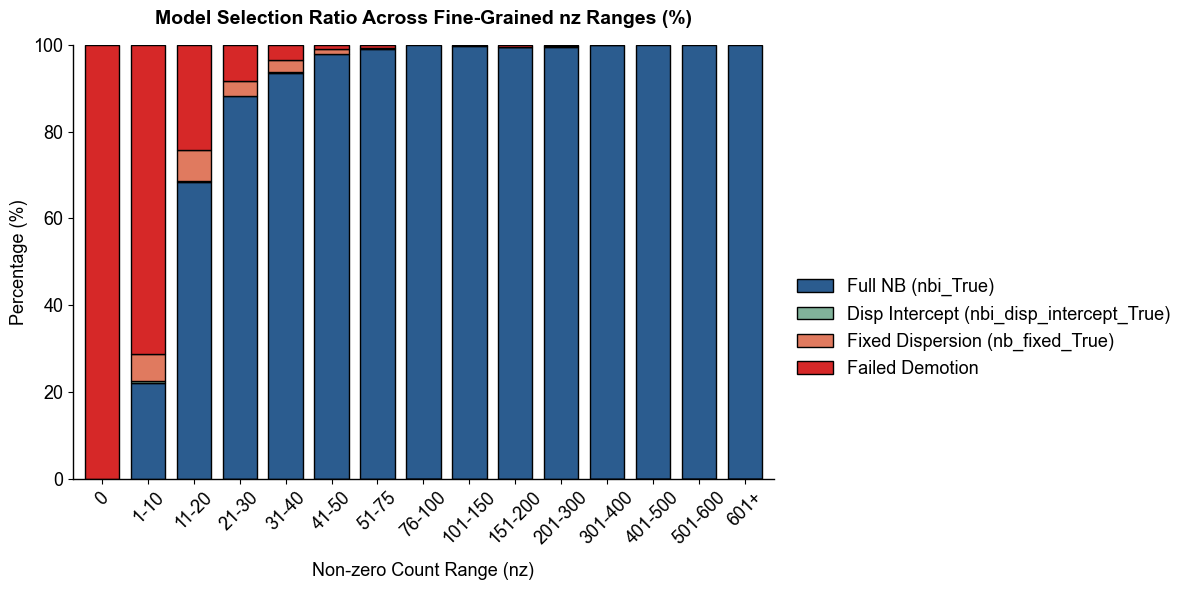

,stage_failure,n,nz_med,mean_hc_med,max_hc_med,zero_frac_med,max_over_mean_med,tau2_med
0,nb_fixed_False,877,5.0,0.023088,6.0,0.992785,297.000000,4.837339e-09
1,nb_fixed_True,135,13.0,0.070707,13.0,0.981241,206.684211,1.277997e-08
2,nbi_True,19080,547.0,32.756133,852.5,0.210678,27.328441,3.402334e-02
3,nbi_disp_intercept_True,5,18.0,0.085137,15.0,0.974026,129.203390,9.262880e-09


In [4]:
stage_order = ['nbi_True', 'nbi_disp_intercept_True', 'nb_fixed_True', 'nb_fixed_False']
stage_labels = {
    'nbi_True': 'Full NB (nbi_True)',
    'nbi_disp_intercept_True': 'Disp Intercept (nbi_disp_intercept_True)',
    'nb_fixed_True': 'Fixed Dispersion (nb_fixed_True)',
    'nb_fixed_False' : 'Failed Demotion'
}

ct_pct = pd.crosstab(summ['nz_group'], summ['stage_failure'], normalize='index') * 100
for stage in stage_order:
    if stage not in ct_pct.columns:
        ct_pct[stage] = 0.0
ct_pct = ct_pct[stage_order]

fig, ax = plt.subplots(figsize=(12, 6))
colors = ['#2b5c8f', '#81b29a', '#e07a5f',  '#d62828',]

ct_pct.plot(
    kind='bar',
    stacked=True,
    ax=ax,
    color=colors,
    edgecolor='black',
    linewidth=1,
    width=0.75
)

ax.set_title('Model Selection Ratio Across Fine-Grained nz Ranges (%)', fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel('Non-zero Count Range (nz)', labelpad=10)
ax.set_ylabel('Percentage (%)')
ax.set_ylim(0, 100)
ax.tick_params(axis='x', rotation=45)
ax.legend([stage_labels[s] for s in stage_order], bbox_to_anchor=(1.01, 0.5), loc='upper left', frameon=False)

plt.tight_layout()
plt.show()

table_summary = summ.groupby("stage_failure").agg(
    n=("gene", "size"),
    nz_med=("nz", "median"),
    mean_hc_med=("mean_hc", "median"),
    max_hc_med=("max_hc", "median"),
    zero_frac_med=("zero_frac", "median"),
    max_over_mean_med=("max_over_mean", "median"),
    tau2_med=("tau2", "median")
).reset_index()

display(table_summary)


/tmp/ipykernel_167537/1342025557.py:15: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[0, 1].boxplot(stage_data, labels=stages, patch_artist=True,


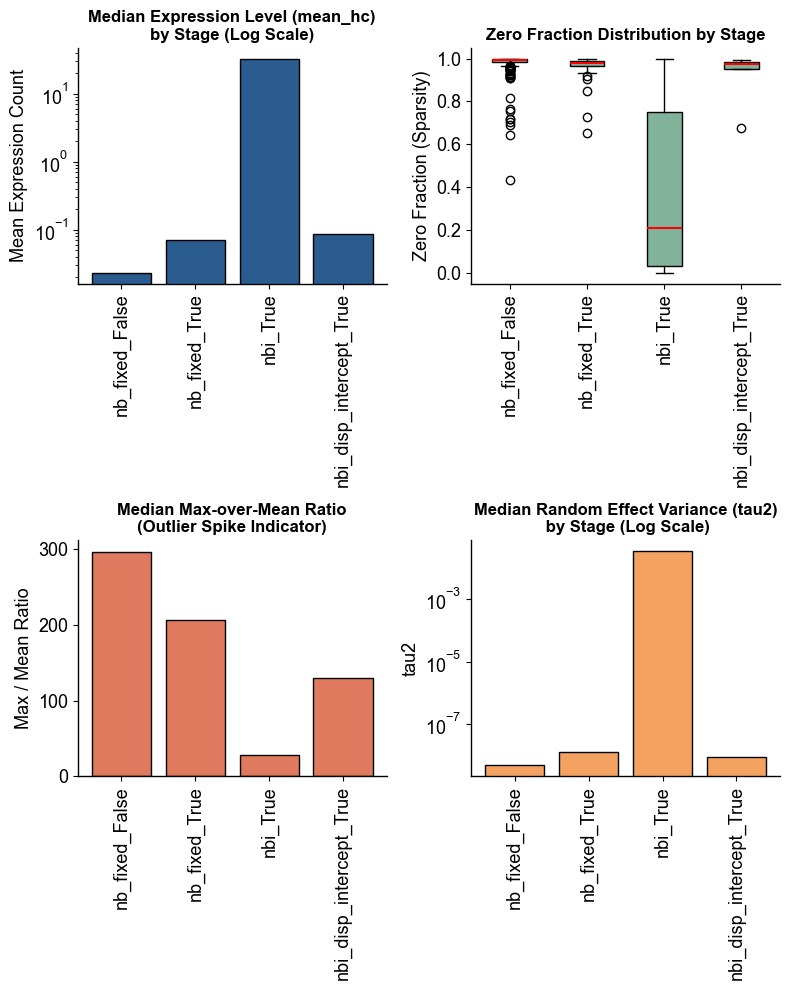

In [5]:
fig, axes = plt.subplots(2, 2, figsize=(8, 10))

stages = table_summary['stage_failure']
means = table_summary['mean_hc_med']

# 1. Median Mean Expression by Stage
axes[0, 0].bar(stages, means, color='#2b5c8f', edgecolor='black')
axes[0, 0].set_yscale('log')
axes[0, 0].set_title('Median Expression Level (mean_hc)\nby Stage (Log Scale)', fontsize=12, fontweight='bold')
axes[0, 0].set_ylabel('Mean Expression Count')
axes[0, 0].tick_params(axis='x', rotation=90)

# 2. Zero Fraction Boxplot
stage_data = [summ[summ['stage_failure'] == s]['zero_frac'].values for s in stages]
axes[0, 1].boxplot(stage_data, labels=stages, patch_artist=True,
                   boxprops=dict(facecolor='#81b29a', color='black'),
                   medianprops=dict(color='red', linewidth=1.5))
axes[0, 1].set_title('Zero Fraction Distribution by Stage', fontsize=12, fontweight='bold')
axes[0, 1].set_ylabel('Zero Fraction (Sparsity)')
axes[0, 1].tick_params(axis='x', rotation=90)

# 3. Max / Mean Outlier Spike Ratio
axes[1, 0].bar(stages, table_summary['max_over_mean_med'], color='#e07a5f', edgecolor='black')
axes[1, 0].set_title('Median Max-over-Mean Ratio\n(Outlier Spike Indicator)', fontsize=12, fontweight='bold')
axes[1, 0].set_ylabel('Max / Mean Ratio')
axes[1, 0].tick_params(axis='x', rotation=90)

# 4. Tau2 (Random Effect Variance) Median
axes[1, 1].bar(stages, table_summary['tau2_med'], color='#f4a261', edgecolor='black')
axes[1, 1].set_yscale('log')
axes[1, 1].set_title('Median Random Effect Variance (tau2)\n by Stage (Log Scale)', fontsize=12, fontweight='bold')
axes[1, 1].set_ylabel('tau2')
axes[1, 1].tick_params(axis='x', rotation=90)

plt.tight_layout()
plt.show()


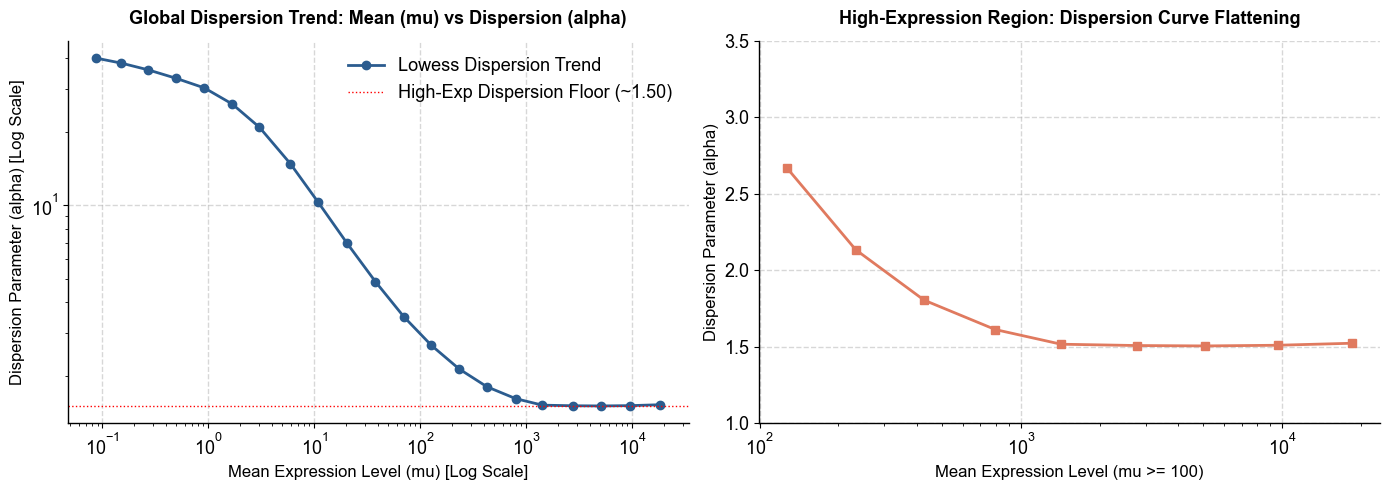

nb_fixed_True 유전자 중 low-nz (nz <= 30) 비중: 113 / 135 (83.7%)
nb_fixed_True 유전자 중 high-exp (mean_hc >= 1.0) 유전자 수: 4개


In [6]:
# Dispersion Trend 곡선 시각화 및 고발현 평탄화(Flattening) 분석
import json

with open('./engine_state_mixed/dispersion_trend.json') as f:
    trend = json.load(f)

logmu = np.array(trend['lowess_logmu'])
logsigma = np.array(trend['lowess_logsigma'])

mu = np.exp(logmu)
alpha = np.exp(logsigma)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# 1. Overall Mean vs Dispersion Trend (Log-Log Scale)
ax1.plot(mu, alpha, marker='o', color='#2b5c8f', linewidth=2, label='Lowess Dispersion Trend')
ax1.set_xscale('log')
ax1.set_yscale('log')
ax1.set_title('Global Dispersion Trend: Mean (mu) vs Dispersion (alpha)', fontsize=13, fontweight='bold', pad=12)
ax1.set_xlabel('Mean Expression Level (mu) [Log Scale]', fontsize=12)
ax1.set_ylabel('Dispersion Parameter (alpha) [Log Scale]', fontsize=12)
ax1.grid(True, linestyle='--', alpha=0.5)
ax1.axhline(y=1.5, color='red', linestyle=':', label='High-Exp Dispersion Floor (~1.50)')
ax1.legend(frameon=False)

# 2. High Expression Region Zoom-in (mu > 100)
high_mask = mu >= 100
ax2.plot(mu[high_mask], alpha[high_mask], marker='s', color='#e07a5f', linewidth=2, label='High-Exp Segment')
ax2.set_xscale('log')
ax2.set_title('High-Expression Region: Dispersion Curve Flattening', fontsize=13, fontweight='bold', pad=12)
ax2.set_xlabel('Mean Expression Level (mu >= 100)', fontsize=12)
ax2.set_ylabel('Dispersion Parameter (alpha)', fontsize=12)
ax2.set_ylim(1.0, 3.5)
ax2.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

# nb_fixed_True 유전자 중 Dispersion Trend 영향 분석
nb_fixed = summ[summ['stage_failure'] == 'nb_fixed_True'].copy()
print(f"nb_fixed_True 유전자 중 low-nz (nz <= 30) 비중: {(nb_fixed['nz'] <= 30).sum()} / {len(nb_fixed)} ({(nb_fixed['nz'] <= 30).mean()*100:.1f}%)")
print(f"nb_fixed_True 유전자 중 high-exp (mean_hc >= 1.0) 유전자 수: {(nb_fixed['mean_hc'] >= 1.0).sum()}개")


In [7]:
import os
import sys
import types
import pickle
import anndata as ad
from scipy.sparse import issparse

# 0. Fix pickle class mapping error for MixedEffectsModeling.model_engine_mixed
from MixedEffectsModeling.core.marginal_rqr import marginal_nb_loglik
import MixedEffectsModeling.core.model_engine_mixed as model_engine_mixed
sys.modules['MixedEffectsModeling.model_engine_mixed'] = model_engine_mixed

# 1. Load data & fitted objects
Xs, Y, batch, gene_names = load_hc()
gmap = {g: i for i, g in enumerate(gene_names)}

with open('./engine_state_mixed/genes.pkl', 'rb') as f:
    genes_fit = pickle.load(f)

X_design = np.hstack([np.ones((Xs.shape[0], 1)), Xs])

In [8]:
from scipy.stats import nbinom
from numpy.polynomial.hermite_e import hermegauss
from tqdm.auto import tqdm
from MixedEffectsModeling.core.marginal_rqr import marginal_nb_rqr
from MixedEffectsModeling.core.calibration import gene_shash_calibration

_HG_NODES, _HG_WEIGHTS = hermegauss(7)
_HG_WEIGHTS = _HG_WEIGHTS / _HG_WEIGHTS.sum()
_TAU2_EPS = 1e-12
PPC_N_REPS = 500
SHASH_MAX_N = 3000
CKPT_PATH = './engine_state_mixed/train_fitness_results_partial.pkl'
CKPT_EVERY = 1000

def nb_marginal_mean_var(mu, alpha, tau2):
    # E[Y]=mu*exp(tau2/2); Var[Y] via E[Y^2|b]=mu*exp(b)+(1+alpha)*(mu*exp(b))^2,
    # integrated analytically over the lognormal random intercept (closed form, no quadrature).
    if tau2 < _TAU2_EPS:
        return mu, mu + alpha * mu ** 2
    mean = mu * np.exp(tau2 / 2)
    ey2 = mu * np.exp(tau2 / 2) + (1 + alpha) * mu ** 2 * np.exp(2 * tau2)
    return mean, ey2 - mean ** 2

def nb_marginal_pmf0(mu, alpha, tau2):
    n_ = 1.0 / np.maximum(alpha, 1e-8)
    if tau2 < _TAU2_EPS:
        p_ = np.clip(n_ / (n_ + mu), 1e-8, 1 - 1e-8)
        return nbinom.pmf(0, n_, p_)
    sd = np.sqrt(tau2)
    total = np.zeros_like(mu)
    for node, w in zip(_HG_NODES, _HG_WEIGHTS):
        mu_b = mu * np.exp(sd * node)
        p_ = np.clip(n_ / (n_ + mu_b), 1e-8, 1 - 1e-8)
        total += w * nbinom.pmf(0, n_, p_)
    return total

def simulate_mixed_many(mu, alpha, tau2, n_reps, seed):
    # posterior-predictive replicates matching marginal_rqr's mixture assumption:
    # b ~ N(0,tau2) per (rep, sample), mu_b = mu*exp(b), y_rep ~ NB(mu_b, alpha).
    rng = np.random.default_rng(seed)
    n_obs = len(mu)
    if tau2 < _TAU2_EPS:
        mu_b = np.broadcast_to(mu, (n_reps, n_obs))
    else:
        b = rng.normal(0.0, np.sqrt(tau2), size=(n_reps, n_obs))
        mu_b = np.clip(mu[None, :] * np.exp(b), 1e-8, 1e10)
    n_ = np.broadcast_to(1.0 / np.maximum(alpha, 1e-8), (n_reps, n_obs))
    p_ = np.clip(n_ / (n_ + mu_b), 1e-10, 1 - 1e-10)
    return rng.negative_binomial(n_, p_)

# 2. Evaluate In-Sample Fit, PPC & SHASH Calibration for all genes
if os.path.exists('./engine_state_mixed/train_fitness_results.pkl'):
    with open('./engine_state_mixed/train_fitness_results.pkl', 'rb') as f:
        df_res = pickle.load(f)
else:
    results = []
    if os.path.exists(CKPT_PATH):
        with open(CKPT_PATH, 'rb') as f:
            results = pickle.load(f)
    done = {r['gene'] for r in results}
    genes_todo = [g for g in summ['gene'].values if g in genes_fit and g not in done]

    for i, g in enumerate(tqdm(genes_todo, desc='in-sample fit')):
        fit_obj = genes_fit[g]
        y = Y[:, gmap[g]]
        n_obs = len(y)
        obs_mean = float(y.mean())
        obs_var = float(y.var())
        obs_nz = int((y > 0).sum())
        if not fit_obj.ok:
            mu = np.full(n_obs, np.maximum(obs_mean, 1e-9))
            alpha = np.full(n_obs, 1.0)
            tau2 = 0.0
        else:
            mu = np.exp(X_design @ np.nan_to_num(fit_obj.mu_coef, nan=0.0)) if fit_obj.mu_coef is not None else np.full(n_obs, np.maximum(obs_mean, 1e-9))
            if fit_obj.disp_coef is not None and not np.all(np.isnan(fit_obj.disp_coef)):
                alpha = np.exp(-X_design @ np.nan_to_num(fit_obj.disp_coef, nan=0.0))
            elif fit_obj.fixed_alpha is not None:
                alpha = np.full(n_obs, fit_obj.fixed_alpha)
            else:
                alpha = np.full(n_obs, 1.0)
            tau2 = fit_obj.tau2 if fit_obj.tau2 is not None else 0.0

        mu_marg, var_marg = nb_marginal_mean_var(mu, alpha, tau2)
        pred_zero_frac = float(np.mean(nb_marginal_pmf0(mu, alpha, tau2)))
        obs_zero_frac = float((y == 0).mean())
        ll_per_sample = marginal_nb_loglik(y, mu, alpha, tau2)
        avg_loglik = float(np.mean(ll_per_sample))
        pred_mean = float(np.mean(mu_marg))
        pred_var = float(np.mean(var_marg))
        pearson_chi2 = float(np.sum(((y - mu_marg) ** 2) / np.maximum(var_marg, 1e-8)) / n_obs)

        seed = 1000 + i
        y_rep = simulate_mixed_many(mu, alpha, tau2, PPC_N_REPS, seed)
        rep_mean = y_rep.mean(axis=1)
        rep_var = y_rep.var(axis=1)
        rep_zero_frac = (y_rep == 0).mean(axis=1)
        rep_chi2 = np.mean((y_rep - mu_marg[None, :]) ** 2 / np.maximum(var_marg[None, :], 1e-8), axis=1)
        ppc_p_mean = float(np.mean(rep_mean >= obs_mean))
        ppc_p_var = float(np.mean(rep_var >= obs_var))
        ppc_p_zero = float(np.mean(rep_zero_frac >= obs_zero_frac))
        ppc_p_chi2 = float(np.mean(rep_chi2 >= pearson_chi2))

        q25, q50, q90, q95, q99 = np.percentile(y_rep, [25, 50, 90, 95, 99], axis=0)
        cov_25 = float(np.mean(y <= q25))
        cov_50 = float(np.mean(y <= q50))
        cov_90 = float(np.mean(y <= q90))
        cov_95 = float(np.mean(y <= q95))
        cov_99 = float(np.mean(y <= q99))

        z = marginal_nb_rqr(y, mu, alpha, tau2, seed=seed + 1)
        z_sub = z if n_obs <= SHASH_MAX_N else np.random.default_rng(seed).choice(z, SHASH_MAX_N, replace=False)
        calib = gene_shash_calibration(z_sub)

        results.append({
            'gene': g,
            'stage_failure': fit_obj.stage + '_' + str(fit_obj.ok),
            'nz': obs_nz,
            'obs_mean': obs_mean,
            'pred_mean': pred_mean,
            'obs_zero_frac': obs_zero_frac,
            'pred_zero_frac': pred_zero_frac,
            'zero_diff': pred_zero_frac - obs_zero_frac,
            'pearson_chi2': pearson_chi2,
            'avg_loglik': avg_loglik,
            'cov_25': cov_25, 'cov_50': cov_50, 'cov_90': cov_90, 'cov_95': cov_95, 'cov_99': cov_99,
            'ppc_p_mean': ppc_p_mean, 'ppc_p_var': ppc_p_var, 'ppc_p_zero': ppc_p_zero, 'ppc_p_chi2': ppc_p_chi2,
            **calib,
        })

        if (i + 1) % CKPT_EVERY == 0:
            with open(CKPT_PATH, 'wb') as f:
                pickle.dump(results, f)

    df_res = pd.DataFrame(results)
    with open('./engine_state_mixed/train_fitness_results.pkl', 'wb') as f:
        pickle.dump(df_res, f)
    if os.path.exists(CKPT_PATH):
        os.remove(CKPT_PATH)

In [9]:
df_res

,gene,stage_failure,nz,obs_mean,pred_mean,obs_zero_frac,pred_zero_frac,zero_diff,pearson_chi2,avg_loglik,...,z_lo,z_hi,raw_skew,raw_kurtosis,corrected_skew,corrected_kurtosis,naive_exceed,shash_exceed,naive_fdr_reject_rate,corr_fdr_reject_rate
0,ENSG00000000003.17,nbi_True,368,7.696970,7.721061e+00,0.468975,0.448592,-2.038348e-02,7.864884e-01,-2.279178e+00,...,-1.959272,1.834663,-0.133154,0.043764,-0.005946,0.109652,0.040404,0.050505,0.000000,0.000000
1,ENSG00000000005.6,nbi_True,74,0.919192,1.237643e+00,0.893218,0.894406,1.188498e-03,1.102692e+00,-5.402302e-01,...,-2.011352,1.949408,0.018543,-0.058336,0.024076,0.014087,0.050505,0.050505,0.000000,0.000000
2,ENSG00000000419.15,nbi_True,673,104.552670,1.216067e+02,0.028860,0.004860,-2.399980e-02,1.009093e+00,-5.016739e+00,...,-2.221937,1.885690,-0.303909,1.811947,0.038109,0.075874,0.062049,0.053391,0.001443,0.000000
3,ENSG00000000457.15,nbi_True,648,72.591631,7.426448e+01,0.064935,0.020306,-4.462944e-02,8.567618e-01,-4.524943e+00,...,-2.172943,1.873589,-0.387940,0.846089,-0.040219,-0.129462,0.063492,0.050505,0.000000,0.000000
4,ENSG00000000460.18,nbi_True,597,76.965368,7.803629e+01,0.138528,0.071105,-6.742333e-02,7.917978e-01,-4.410551e+00,...,-2.008248,1.784521,-0.026430,0.087572,0.005597,-0.055208,0.046176,0.053391,0.000000,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
20092,ENSG00000310576.1,nbi_True,507,33.750361,3.588826e+01,0.268398,0.209092,-5.930587e-02,7.979499e-01,-3.377889e+00,...,-2.171102,1.773170,-0.280944,0.027489,0.075641,-0.045298,0.047619,0.041847,0.000000,0.000000
20093,ENSG00000310579.1,nbi_True,151,4.051948,3.505054e+00,0.782107,0.781569,-5.375345e-04,1.156936e+00,-1.087965e+00,...,-2.027036,1.884896,-0.107483,0.089733,0.028684,0.085049,0.046176,0.049062,0.000000,0.000000
20094,ENSG00000310583.1,nbi_True,228,3.274170,3.376219e+00,0.670996,0.646618,-2.437746e-02,1.785276e+00,-1.531989e+00,...,-2.163257,1.832800,-0.142162,0.542550,0.083048,0.236329,0.056277,0.046176,0.001443,0.001443
20095,ENSG00000310590.1,nb_fixed_False,0,0.000000,1.000000e-09,1.000000,1.000000,-1.000000e-08,1.000000e-10,-1.000000e-08,...,-1.920261,1.955090,0.088305,0.052123,-0.027725,0.078013,0.046176,0.049062,0.000000,0.000000


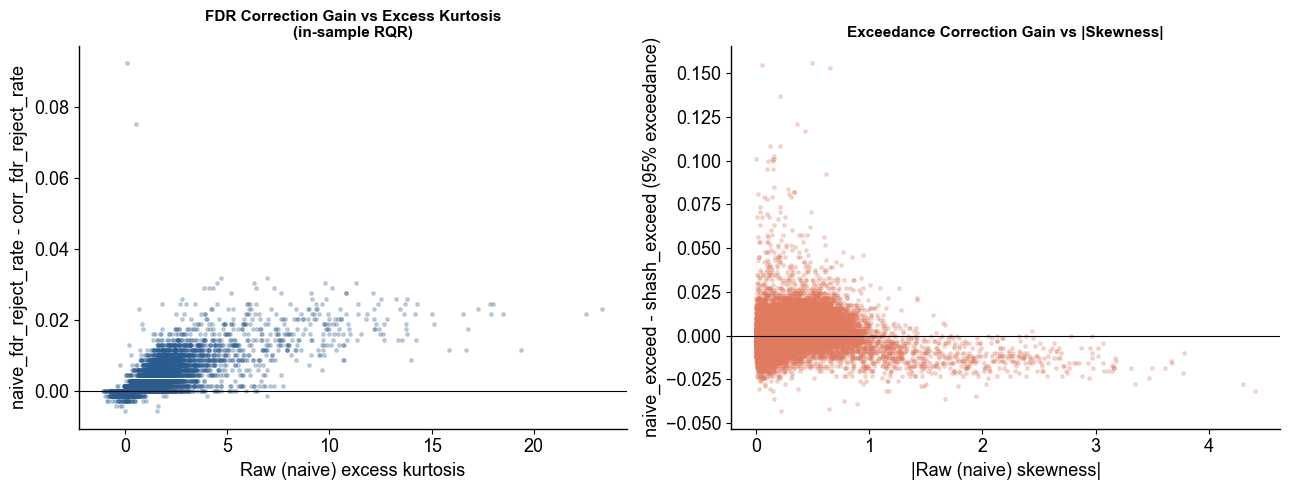

shash_ok genes: 19218 / 20097
corr(raw_kurtosis, fdr_gain) = 0.771
corr(|raw_skew|, exceed_gain) = -0.034


In [10]:
# 3. SHASH Calibration Gain vs Raw Skew/Kurtosis
calib_df = df_res[df_res['shash_ok'] & df_res['stage_failure'].str.endswith('True')].copy()
calib_df['fdr_gain'] = calib_df['naive_fdr_reject_rate'] - calib_df['corr_fdr_reject_rate']
calib_df['exceed_gain'] = calib_df['naive_exceed'] - calib_df['shash_exceed']

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].scatter(calib_df['raw_kurtosis'], calib_df['fdr_gain'], s=6, alpha=0.25, color='#2b5c8f')
axes[0].axhline(0, color='black', linewidth=0.8)
axes[0].set_xlabel('Raw (naive) excess kurtosis')
axes[0].set_ylabel('naive_fdr_reject_rate - corr_fdr_reject_rate')
axes[0].set_title('FDR Correction Gain vs Excess Kurtosis\n(in-sample RQR)', fontsize=11, fontweight='bold')

axes[1].scatter(calib_df['raw_skew'].abs(), calib_df['exceed_gain'], s=6, alpha=0.25, color='#e07a5f')
axes[1].axhline(0, color='black', linewidth=0.8)
axes[1].set_xlabel('|Raw (naive) skewness|')
axes[1].set_ylabel('naive_exceed - shash_exceed (95% exceedance)')
axes[1].set_title('Exceedance Correction Gain vs |Skewness|', fontsize=11, fontweight='bold')

plt.tight_layout()
plt.show()

print(f"shash_ok genes: {len(calib_df)} / {len(df_res)}")
print(f"corr(raw_kurtosis, fdr_gain) = {calib_df['raw_kurtosis'].corr(calib_df['fdr_gain']):.3f}")
print(f"corr(|raw_skew|, exceed_gain) = {calib_df['raw_skew'].abs().corr(calib_df['exceed_gain']):.3f}")

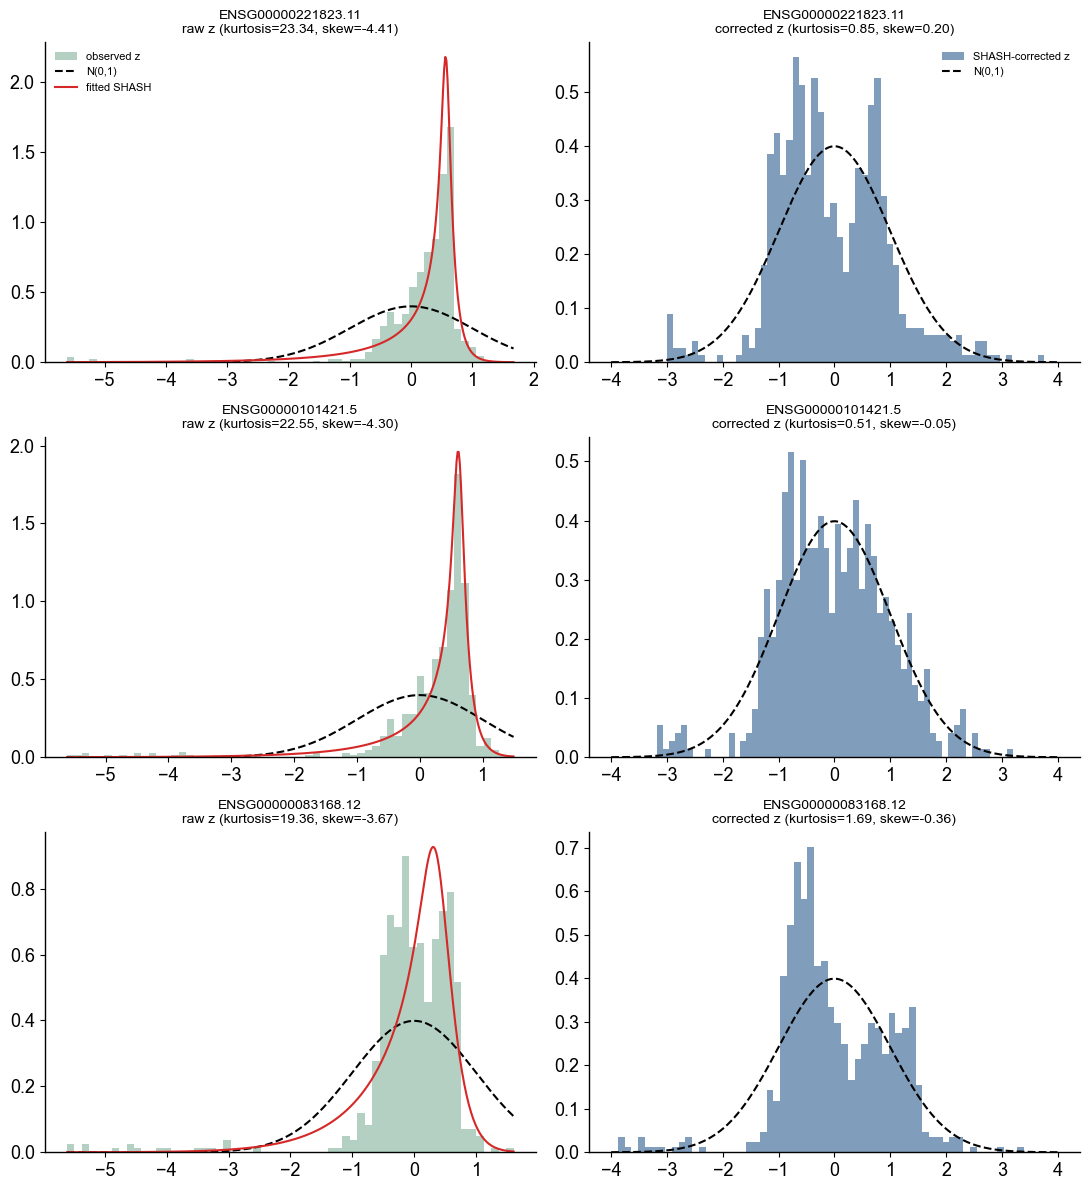

In [11]:
# 4. Example Genes: Raw vs SHASH-Corrected z Distribution (most extreme raw kurtosis)
from MixedEffectsModeling.core.shash import shash_logpdf, shash_transform_to_z
from scipy.stats import norm as _norm

def _gene_mu_alpha_tau2(fit_obj, obs_mean, n_obs):
    if not fit_obj.ok:
        return np.full(n_obs, np.maximum(obs_mean, 1e-9)), np.full(n_obs, 1.0), 0.0
    mu = np.exp(X_design @ np.nan_to_num(fit_obj.mu_coef, nan=0.0)) if fit_obj.mu_coef is not None else np.full(n_obs, np.maximum(obs_mean, 1e-9))
    if fit_obj.disp_coef is not None and not np.all(np.isnan(fit_obj.disp_coef)):
        alpha = np.exp(-X_design @ np.nan_to_num(fit_obj.disp_coef, nan=0.0))
    elif fit_obj.fixed_alpha is not None:
        alpha = np.full(n_obs, fit_obj.fixed_alpha)
    else:
        alpha = np.full(n_obs, 1.0)
    tau2 = fit_obj.tau2 if fit_obj.tau2 is not None else 0.0
    return mu, alpha, tau2

top_genes = calib_df.assign(abs_kurt=calib_df['raw_kurtosis'].abs()).nlargest(3, 'abs_kurt')

fig, axes = plt.subplots(3, 2, figsize=(11, 12))
for row, (_, rec) in enumerate(top_genes.iterrows()):
    g = rec['gene']
    fit_obj = genes_fit[g]
    y = Y[:, gmap[g]]
    n_obs = len(y)
    obs_mean = float(y.mean())
    mu, alpha, tau2 = _gene_mu_alpha_tau2(fit_obj, obs_mean, n_obs)
    z = marginal_nb_rqr(y, mu, alpha, tau2, seed=7)
    z = z[np.isfinite(z)]
    xi, eta, eps, delta = rec['shash_xi'], rec['shash_eta'], rec['shash_eps'], rec['shash_delta']
    z_corr = shash_transform_to_z(z, xi, eta, eps, delta)

    grid = np.linspace(z.min(), z.max(), 400)
    ax = axes[row, 0]
    ax.hist(z, bins=60, density=True, color='#81b29a', alpha=0.6, label='observed z')
    ax.plot(grid, _norm.pdf(grid), color='black', linewidth=1.5, linestyle='--', label='N(0,1)')
    ax.plot(grid, np.exp(shash_logpdf(grid, xi, eta, eps, delta)), color='#d62828', linewidth=1.5, label='fitted SHASH')
    ax.set_title(f'{g}\nraw z (kurtosis={rec["raw_kurtosis"]:.2f}, skew={rec["raw_skew"]:.2f})', fontsize=10)
    if row == 0:
        ax.legend(frameon=False, fontsize=8)

    ax2 = axes[row, 1]
    grid_c = np.linspace(-4, 4, 400)
    ax2.hist(z_corr, bins=60, density=True, color='#2b5c8f', alpha=0.6, label='SHASH-corrected z')
    ax2.plot(grid_c, _norm.pdf(grid_c), color='black', linewidth=1.5, linestyle='--', label='N(0,1)')
    ax2.set_title(f'{g}\ncorrected z (kurtosis={rec["corrected_kurtosis"]:.2f}, skew={rec["corrected_skew"]:.2f})', fontsize=10)
    if row == 0:
        ax2.legend(frameon=False, fontsize=8)

plt.tight_layout()
plt.show()

In [12]:
summ

,gene,route,stage,nz,ok,singular,tau2,fail_reason,nbi_reject_reason,nbi_disp_intercept_reject_reason,nb_fixed_reject_reason,mean_hc,max_hc,zero_frac,var_hc,max_over_mean,stage_failure,nz_group
0,ENSG00000000003.17,model,nbi,368,True,False,5.243433e-02,NaN,NaN,NaN,NaN,7.696970,302.0,0.468975,662.343959,39.236220,nbi_True,301-400
1,ENSG00000000005.6,model,nbi,74,True,False,1.089268e+00,NaN,NaN,NaN,NaN,0.919192,242.0,0.893218,98.299386,263.274725,nbi_True,51-75
2,ENSG00000000419.15,model,nbi,673,True,False,1.325264e-01,NaN,NaN,NaN,NaN,104.552670,1028.0,0.028860,19034.584888,9.832365,nbi_True,601+
3,ENSG00000000457.15,model,nbi,648,True,False,1.456556e-09,NaN,NaN,NaN,NaN,72.591631,907.0,0.064935,13363.690377,12.494553,nbi_True,601+
4,ENSG00000000460.18,model,nbi,597,True,False,5.040334e-02,NaN,NaN,NaN,NaN,76.965368,1619.0,0.138528,18201.635164,21.035435,nbi_True,501-600
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
20092,ENSG00000310576.1,model,nbi,507,True,False,8.669425e-03,NaN,NaN,NaN,NaN,33.750361,1391.0,0.268398,11279.835227,41.214374,nbi_True,501-600
20093,ENSG00000310579.1,model,nbi,151,True,False,1.217005e-01,NaN,NaN,NaN,NaN,4.051948,1194.0,0.782107,2251.899177,294.673077,nbi_True,151-200
20094,ENSG00000310583.1,model,nbi,228,True,False,2.829898e-08,NaN,NaN,NaN,NaN,3.274170,124.0,0.670996,101.771873,37.872190,nbi_True,201-300
20095,ENSG00000310590.1,excluded,nb_fixed,0,False,False,8.615440e-17,not_converged_or_explosion_or_tau2_bound,not_converged_or_explosion_or_tau2_bound,not_converged_or_explosion_or_tau2_bound,not_converged_or_explosion_or_tau2_bound,0.000000,0.0,1.000000,0.000000,0.000000,nb_fixed_False,0


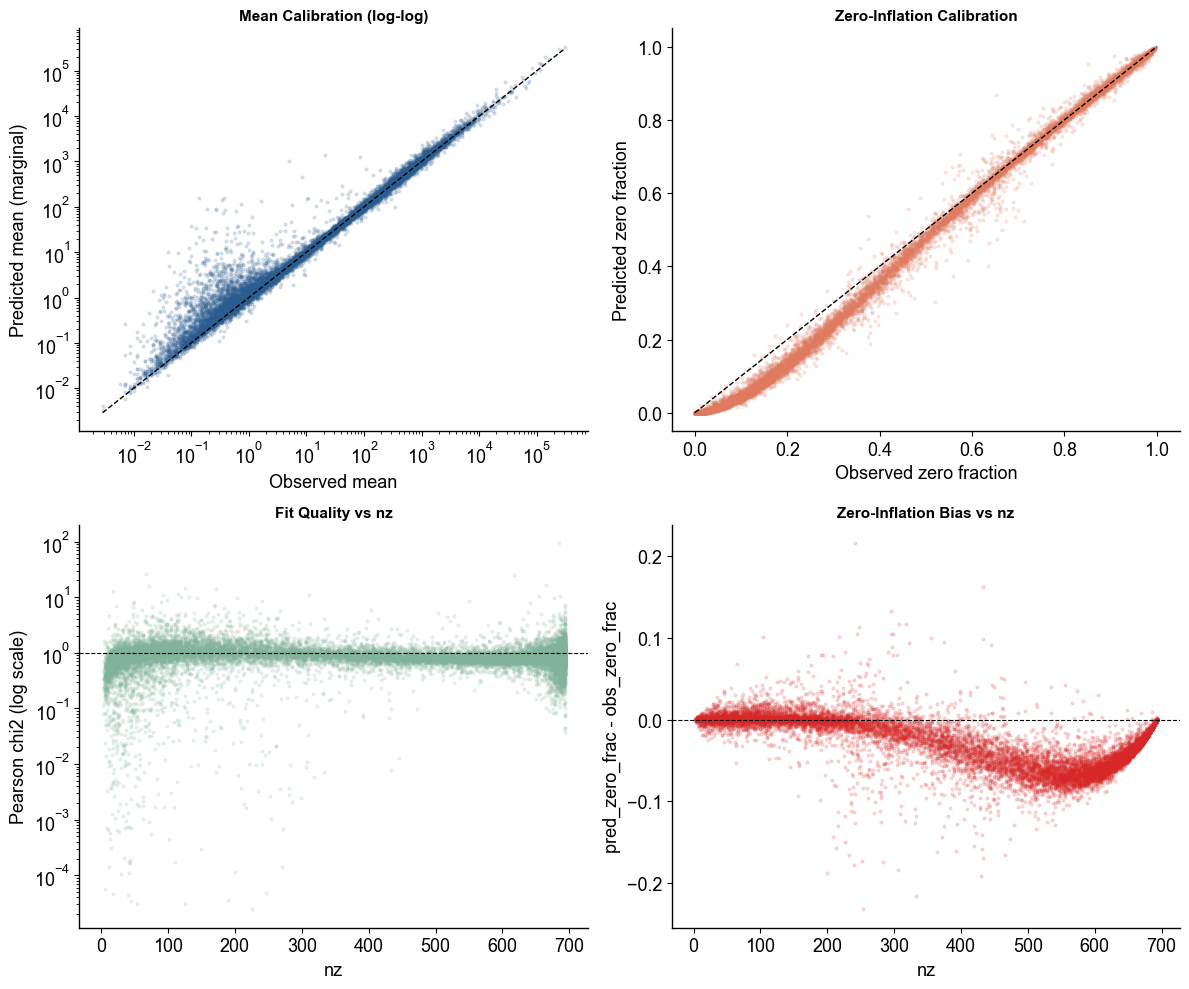

n genes plotted: 19220
median pearson_chi2: 0.841
median |zero_diff|: 0.0156


In [13]:
# 5. PPC Scatter: predicted vs observed (in-sample)
ok_res = df_res[df_res['stage_failure'].str.endswith('True')].copy()

fig, axes = plt.subplots(2, 2, figsize=(12, 10))

axes[0, 0].scatter(ok_res['obs_mean'], ok_res['pred_mean'], s=4, alpha=0.15, color='#2b5c8f')
lims = [max(ok_res['obs_mean'].min(), 1e-3), ok_res['obs_mean'].max()]
axes[0, 0].plot(lims, lims, color='black', linewidth=1, linestyle='--')
axes[0, 0].set_xscale('log'); axes[0, 0].set_yscale('log')
axes[0, 0].set_xlabel('Observed mean'); axes[0, 0].set_ylabel('Predicted mean (marginal)')
axes[0, 0].set_title('Mean Calibration (log-log)', fontsize=11, fontweight='bold')

axes[0, 1].scatter(ok_res['obs_zero_frac'], ok_res['pred_zero_frac'], s=4, alpha=0.15, color='#e07a5f')
axes[0, 1].plot([0, 1], [0, 1], color='black', linewidth=1, linestyle='--')
axes[0, 1].set_xlabel('Observed zero fraction'); axes[0, 1].set_ylabel('Predicted zero fraction')
axes[0, 1].set_title('Zero-Inflation Calibration', fontsize=11, fontweight='bold')

axes[1, 0].scatter(ok_res['nz'], ok_res['pearson_chi2'], s=4, alpha=0.15, color='#81b29a')
axes[1, 0].axhline(1.0, color='black', linewidth=0.8, linestyle='--')
axes[1, 0].set_yscale('log')
axes[1, 0].set_xlabel('nz'); axes[1, 0].set_ylabel('Pearson chi2 (log scale)')
axes[1, 0].set_title('Fit Quality vs nz', fontsize=11, fontweight='bold')

axes[1, 1].scatter(ok_res['nz'], ok_res['zero_diff'], s=4, alpha=0.15, color='#d62828')
axes[1, 1].axhline(0, color='black', linewidth=0.8, linestyle='--')
axes[1, 1].set_xlabel('nz'); axes[1, 1].set_ylabel('pred_zero_frac - obs_zero_frac')
axes[1, 1].set_title('Zero-Inflation Bias vs nz', fontsize=11, fontweight='bold')

plt.tight_layout()
plt.show()

print(f"n genes plotted: {len(ok_res)}")
print(f"median pearson_chi2: {ok_res['pearson_chi2'].median():.3f}")
print(f"median |zero_diff|: {ok_res['zero_diff'].abs().median():.4f}")

/tmp/ipykernel_167537/2937112044.py:32: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[0].boxplot([coefs[:, j] for j in range(coefs.shape[1])], labels=coef_names, showfliers=False)


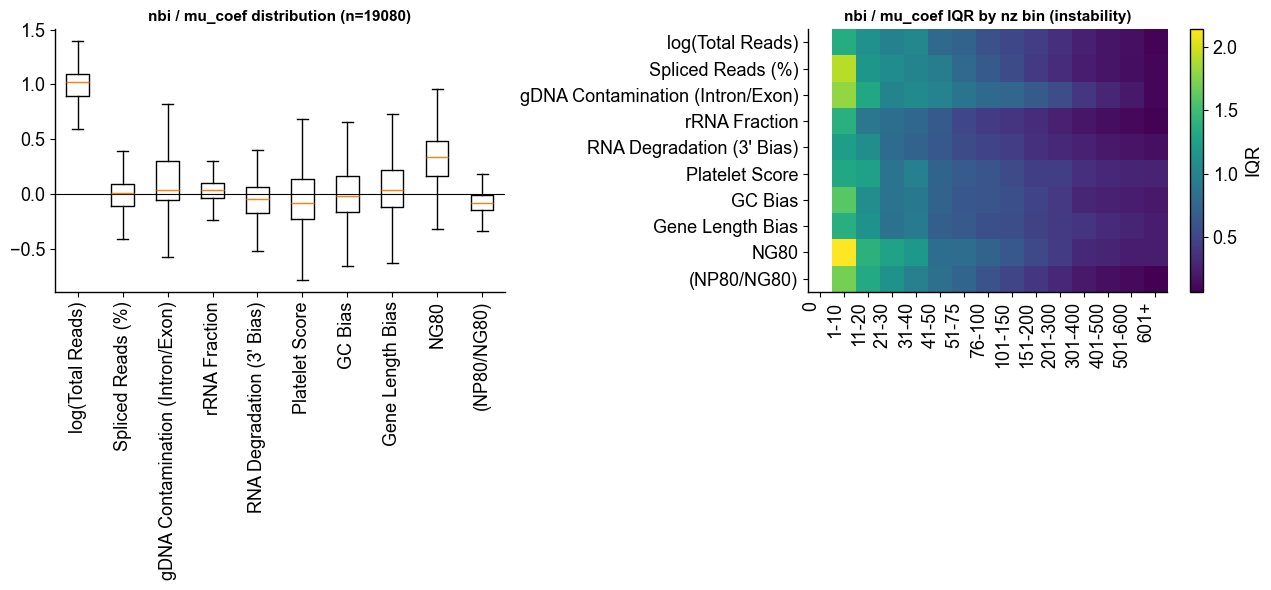

/tmp/ipykernel_167537/2937112044.py:32: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[0].boxplot([coefs[:, j] for j in range(coefs.shape[1])], labels=coef_names, showfliers=False)


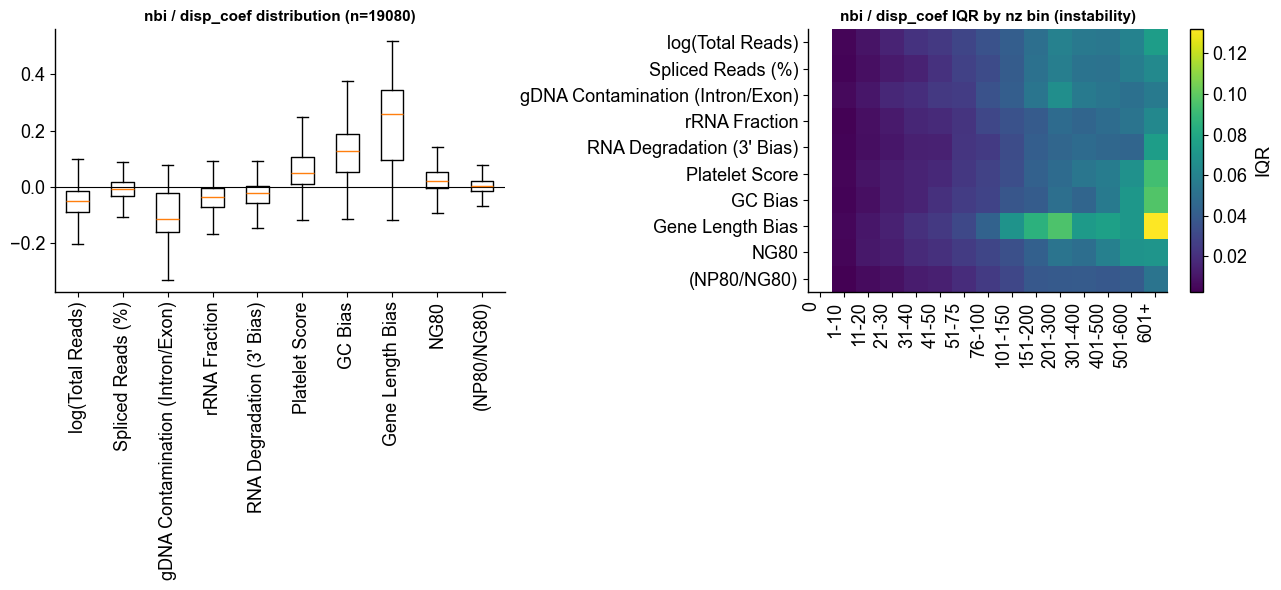

/tmp/ipykernel_167537/2937112044.py:32: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[0].boxplot([coefs[:, j] for j in range(coefs.shape[1])], labels=coef_names, showfliers=False)


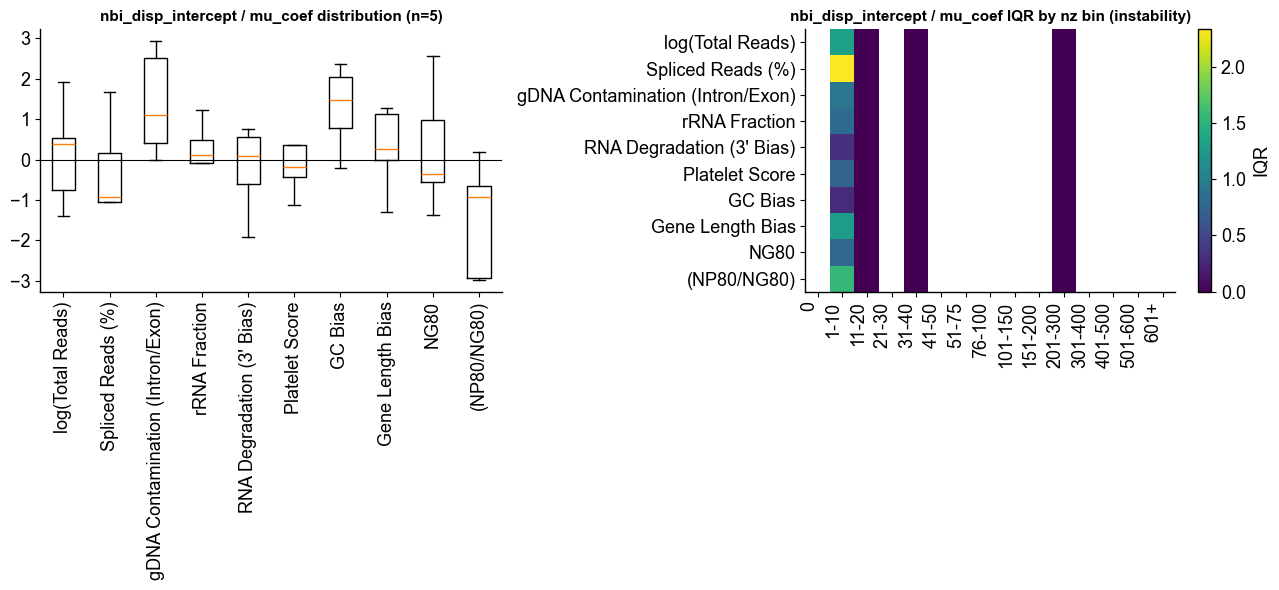

/tmp/ipykernel_167537/2937112044.py:32: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[0].boxplot([coefs[:, j] for j in range(coefs.shape[1])], labels=coef_names, showfliers=False)


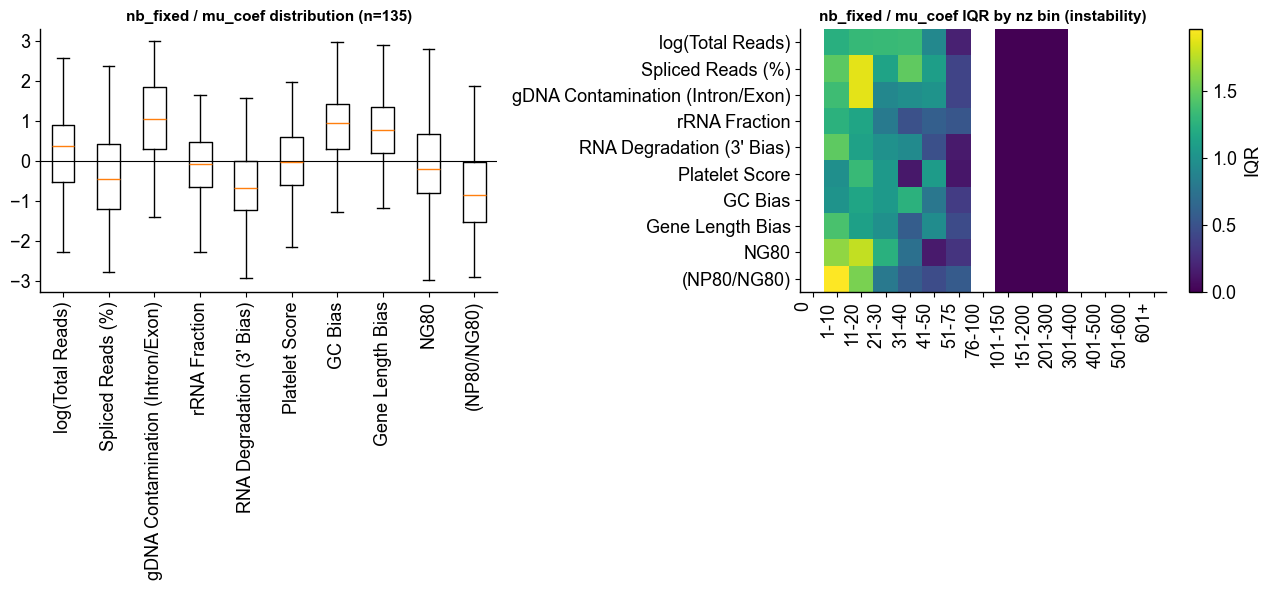

In [22]:
# 6. Parameter-Level Analysis: coefficients per stage, distribution + nz-level variability
# Intercept excluded from these plots (~ log(mean_hc), see prior cell -- not comparable on this scale).
# nbi has a full covariate regression on both mu and dispersion; nbi_disp_intercept/nb_fixed
# only regress mu (dispersion is intercept-only or trend-fixed), so only 'mu' is shown for those.
coef_names = config.BIAS_COLUMNS
STAGE_SUBMODELS = [('nbi', 'mu'), ('nbi', 'disp'), ('nbi_disp_intercept', 'mu'), ('nb_fixed', 'mu')]

def _gene_coefs(genes, coef_type):
    out = []
    for g in genes:
        fo = genes_fit[g]
        c = fo.mu_coef if coef_type == 'mu' else fo.disp_coef
        if c is None or np.all(np.isnan(c)):
            continue
        out.append((g, c[1:]))
    return out

nz_of_gene = summ.set_index('gene')['nz']

for stage, coef_type in STAGE_SUBMODELS:
    genes = summ.loc[(summ['stage'] == stage) & (summ['ok']), 'gene'].values
    recs = _gene_coefs(genes, coef_type)
    if not recs:
        print(f'{stage} / {coef_type}_coef: no genes')
        continue
    gnames = [r[0] for r in recs]
    coefs = np.array([r[1] for r in recs])
    nz_arr = nz_of_gene.loc[gnames].values
    nz_bin = pd.cut(nz_arr, bins=bins, labels=labels)

    fig, axes = plt.subplots(1, 2, figsize=(13, 6))
    axes[0].boxplot([coefs[:, j] for j in range(coefs.shape[1])], labels=coef_names, showfliers=False)
    axes[0].axhline(0, color='black', linewidth=0.8)
    axes[0].set_title(f'{stage} / {coef_type}_coef distribution (n={len(coefs)})', fontsize=11, fontweight='bold')
    axes[0].tick_params(axis='x', rotation=90)

    iqr_grid = np.full((coefs.shape[1], len(labels)), np.nan)
    for bi, lbl in enumerate(labels):
        mask = np.asarray(nz_bin == lbl)
        if not mask.any():
            continue
        q75, q25 = np.percentile(coefs[mask], [75, 25], axis=0)
        iqr_grid[:, bi] = q75 - q25

    im = axes[1].imshow(iqr_grid, aspect='auto', cmap='viridis')
    axes[1].set_yticks(range(len(coef_names))); axes[1].set_yticklabels(coef_names)
    axes[1].set_xticks(range(len(labels))); axes[1].set_xticklabels(labels, rotation=90, ha='right')
    axes[1].set_title(f'{stage} / {coef_type}_coef IQR by nz bin (instability)', fontsize=11, fontweight='bold')
    plt.colorbar(im, ax=axes[1], label='IQR')

    plt.tight_layout()
    plt.show()

/tmp/ipykernel_167537/421776138.py:9: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[0].boxplot(tau2_by_stage, labels=stage_groups, showfliers=False)


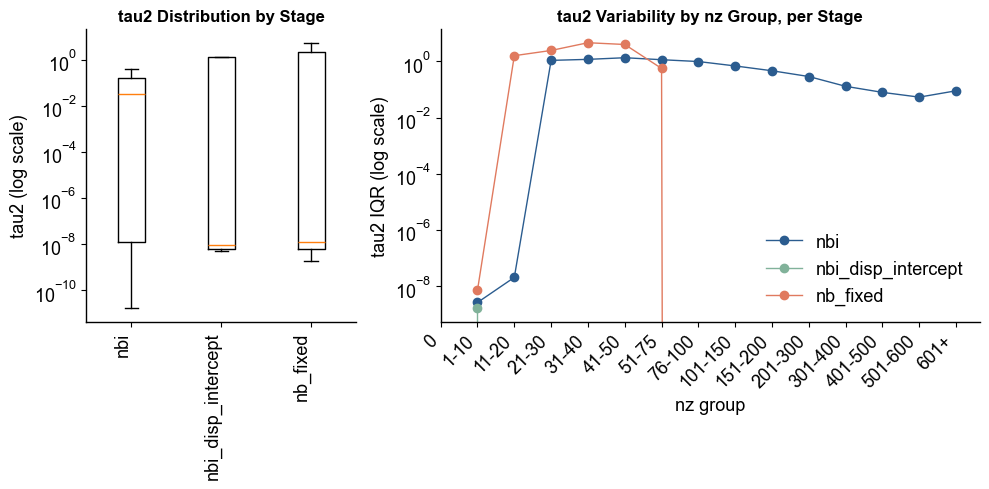

In [ ]:
# 7. Batch Variance (tau2): distribution by stage + nz-level variability, one panel
ok_summ = summ[summ['ok']]
stage_groups = [s for s in ['nbi', 'nbi_disp_intercept', 'nb_fixed'] if s in ok_summ['stage'].unique()]
stage_colors = {'nbi': '#2b5c8f', 'nbi_disp_intercept': '#81b29a', 'nb_fixed': '#e07a5f'}

fig, axes = plt.subplots(1, 2, figsize=(9, 5), width_ratios=[1,2])

tau2_by_stage = [ok_summ.loc[ok_summ['stage'] == s, 'tau2'].dropna() for s in stage_groups]
axes[0].boxplot(tau2_by_stage, labels=stage_groups, showfliers=False)
axes[0].set_yscale('log')
axes[0].set_ylabel('tau2 (log scale)')
axes[0].set_title('tau2 Distribution by Stage', fontsize=12, fontweight='bold')
axes[0].set_xticklabels(stage_groups, rotation=90, ha='right')

for stage in stage_groups:
    g_stage = ok_summ[ok_summ['stage'] == stage]
    tau2 = g_stage['tau2'].values
    nz_bin = pd.cut(g_stage['nz'].values, bins=bins, labels=labels)
    present_idx, iqr_by_bin = [], []
    for bi, lbl in enumerate(labels):
        mask = np.asarray(nz_bin == lbl)
        if not mask.any():
            continue
        q75, q25 = np.percentile(tau2[mask], [75, 25])
        present_idx.append(bi)
        iqr_by_bin.append(q75 - q25)
    axes[1].plot(present_idx, iqr_by_bin, marker='o', color=stage_colors[stage], label=stage)

axes[1].set_yscale('log')
axes[1].set_xticks(range(len(labels)))
axes[1].set_xticklabels(labels, rotation=45, ha='right')
axes[1].set_ylabel('tau2 IQR (log scale)')
axes[1].set_xlabel('nz group')
axes[1].set_title('tau2 Variability by nz Group, per Stage', fontsize=12, fontweight='bold')
axes[1].legend(frameon=False)

plt.tight_layout()
plt.show()